<a href="https://colab.research.google.com/github/farridfaqih-beep/Statistika/blob/main/STATISTIKA_F5512510007_Muhammad_Fariid_Faqih.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [59]:
import os

for root, dirs, files in os.walk('/content'):
    for file in files:
        if file.endswith('HDI Unemployment and Education - Data Indonesia Provinces (2017-2023).csv'):
            print(os.path.join(root, file))

/content/HDI Unemployment and Education - Data Indonesia Provinces (2017-2023).csv
/content/drive/MyDrive/Colab Notebooks/HDI Unemployment and Education - Data Indonesia Provinces (2017-2023).csv


In [60]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
import pandas as pd

# Membaca file CSV
df = pd.read_csv('HDI Unemployment and Education - Data Indonesia Provinces (2017-2023).csv')

# Menampilkan semua baris dan kolom
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print(df)

                 Provinsi  Tingkat Pengangguran Terbuka (TPT) - Februari  \
0                    ACEH                                           7.39   
1          SUMATERA UTARA                                           6.41   
2          SUMATERA BARAT                                           5.80   
3                    RIAU                                           5.76   
4                   JAMBI                                           3.67   
5        SUMATERA SELATAN                                           3.80   
6                BENGKULU                                           2.81   
7                 LAMPUNG                                           4.43   
8    KEP. BANGKA BELITUNG                                           4.46   
9               KEP. RIAU                                           6.44   
10            DKI JAKARTA                                           5.36   
11             JAWA BARAT                                           8.49   
12          

In [62]:
print(df.columns.tolist())

['Provinsi', 'Tingkat Pengangguran Terbuka (TPT) - Februari', 'Tingkat Pengangguran Terbuka (TPT) - Agustus', 'Tingkat Partisipasi Angkatan Kerja (TPAK) - Februari', 'Tingkat Partisipasi Angkatan Kerja (TPAK) - Agustus', 'Tahun', 'Indeks Pembangunan Manusia', 'Rata-rata Lama Sekolah']


In [63]:
X = df[
    [
        'Tingkat Partisipasi Angkatan Kerja (TPAK) - Agustus',
        'Indeks Pembangunan Manusia',
        'Rata-rata Lama Sekolah',
        'Tahun'
    ]
]

y = df[
    'Tingkat Pengangguran Terbuka (TPT) - Agustus'
]

In [64]:
print("Variabel Bebas (X)")
display(X.head())

print("\nVariabel Terikat (Y)")
display(y.head())

Variabel Bebas (X)


,Tingkat Partisipasi Angkatan Kerja (TPAK) - Agustus,Indeks Pembangunan Manusia,Rata-rata Lama Sekolah,Tahun
0,63.74,70.60,8.98,2017
1,68.88,70.57,9.25,2017
2,66.29,71.24,8.72,2017
3,64.00,71.79,8.76,2017
4,67.52,69.99,8.15,2017



Variabel Terikat (Y)


,Tingkat Pengangguran Terbuka (TPT) - Agustus
0,6.57
1,5.60
2,5.58
3,6.22
4,3.87


In [65]:
from sklearn.model_selection import train_test_split

X_latih, X_uji, y_latih, y_uji = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [66]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(
    X_latih,
    y_latih
)

print("Model berhasil dibuat")

Model berhasil dibuat


In [67]:
print("Konstanta (a)")
print(model.intercept_)

print("\nKoefisien Regresi")

for nama, nilai in zip(
    X.columns,
    model.coef_
):
    print(f"{nama} = {nilai:.4f}")

Konstanta (a)
38.077834022737875

Koefisien Regresi
Tingkat Partisipasi Angkatan Kerja (TPAK) - Agustus = -0.2468
Indeks Pembangunan Manusia = 0.0099
Rata-rata Lama Sekolah = 0.5497
Tahun = -0.0107


In [68]:
print(f"""
Persamaan Regresi Linear Berganda

Y =
{model.intercept_:.4f}
+ ({model.coef_[0]:.4f}) TPAK
+ ({model.coef_[1]:.4f}) IPM
+ ({model.coef_[2]:.4f}) RLS
+ ({model.coef_[3]:.4f}) Tahun
""")


Persamaan Regresi Linear Berganda

Y =
38.0778
+ (-0.2468) TPAK
+ (0.0099) IPM
+ (0.5497) RLS
+ (-0.0107) Tahun



In [69]:
y_prediksi = model.predict(X_uji)

y_prediksi[:10]

array([7.1600842 , 4.68974088, 4.35036678, 5.03177755, 6.87431298,
       5.0591764 , 2.70945165, 4.14617525, 6.17305034, 5.99598001])

In [70]:
import pandas as pd

perbandingan = pd.DataFrame({
    'Data Asli': y_uji.values,
    'Hasil Prediksi': y_prediksi
})

perbandingan

,Data Asli,Hasil Prediksi
0,7.18,7.160084
1,3.74,4.689741
2,4.56,4.350367
3,5.94,5.031778
4,6.61,6.874313
5,6.28,5.059176
6,3.54,2.709452
7,5.81,4.146175
8,7.16,6.173050
9,4.81,5.995980


In [71]:
perbandingan = pd.DataFrame({
    'Data Asli': y_uji.values,
    'Hasil Prediksi': y_prediksi
})

perbandingan['Selisih Error'] = abs(
    perbandingan['Data Asli'] -
    perbandingan['Hasil Prediksi']
)

perbandingan.head(20)

,Data Asli,Hasil Prediksi,Selisih Error
0,7.18,7.160084,0.019916
1,3.74,4.689741,0.949741
2,4.56,4.350367,0.209633
3,5.94,5.031778,0.908222
4,6.61,6.874313,0.264313
5,6.28,5.059176,1.220824
6,3.54,2.709452,0.830548
7,5.81,4.146175,1.663825
8,7.16,6.173050,0.986950
9,4.81,5.995980,1.185980


In [72]:
print("Perbandingan Data Aktual dan Prediksi")

perbandingan.head(20)

Perbandingan Data Aktual dan Prediksi


,Data Asli,Hasil Prediksi,Selisih Error
0,7.18,7.160084,0.019916
1,3.74,4.689741,0.949741
2,4.56,4.350367,0.209633
3,5.94,5.031778,0.908222
4,6.61,6.874313,0.264313
5,6.28,5.059176,1.220824
6,3.54,2.709452,0.830548
7,5.81,4.146175,1.663825
8,7.16,6.173050,0.986950
9,4.81,5.995980,1.185980


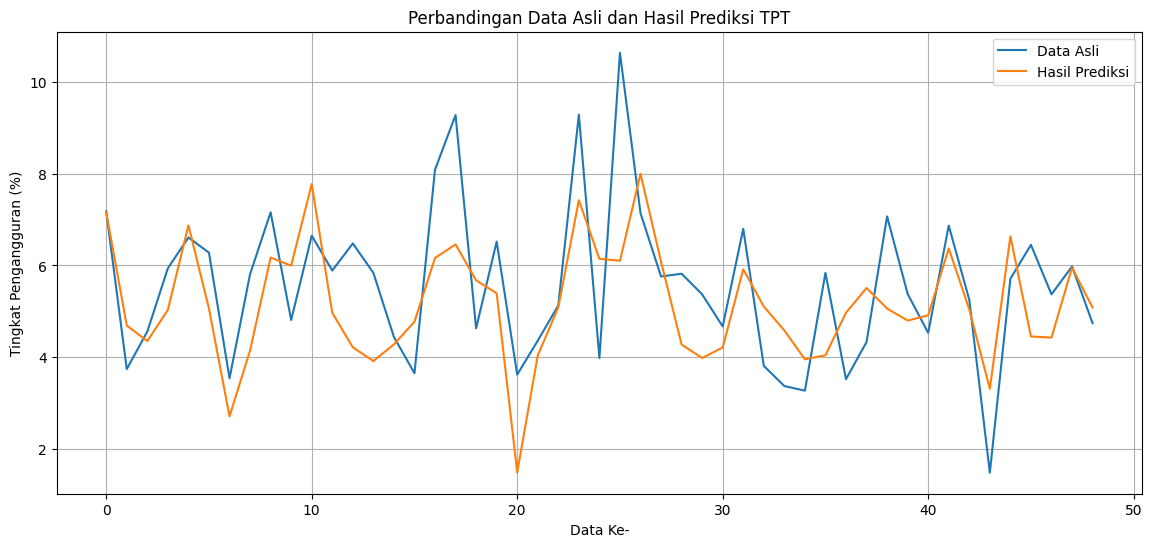

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    perbandingan['Data Asli'].reset_index(drop=True),
    label='Data Asli'
)

plt.plot(
    perbandingan['Hasil Prediksi'].reset_index(drop=True),
    label='Hasil Prediksi'
)

plt.title(
    'Perbandingan Data Asli dan Hasil Prediksi TPT'
)

plt.xlabel('Data Ke-')

plt.ylabel('Tingkat Pengangguran (%)')

plt.legend()

plt.grid(True)

plt.show()

<Figure size 1400x600 with 0 Axes>

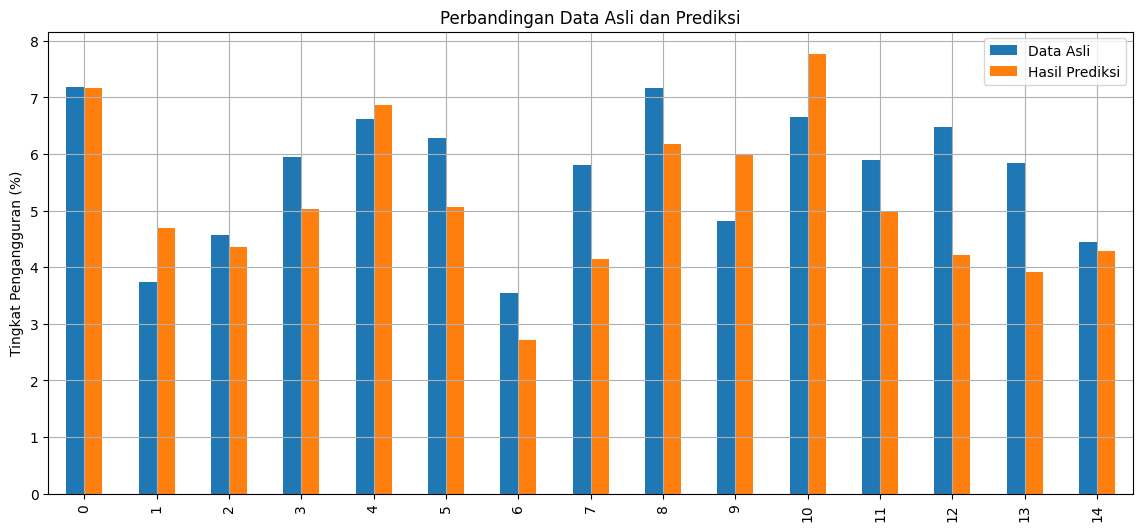

In [74]:
plt.figure(figsize=(14,6))

perbandingan.head(15)[
    ['Data Asli','Hasil Prediksi']
].plot(
    kind='bar',
    figsize=(14,6)
)

plt.title(
    'Perbandingan Data Asli dan Prediksi'
)

plt.ylabel(
    'Tingkat Pengangguran (%)'
)

plt.grid(True)

plt.show()

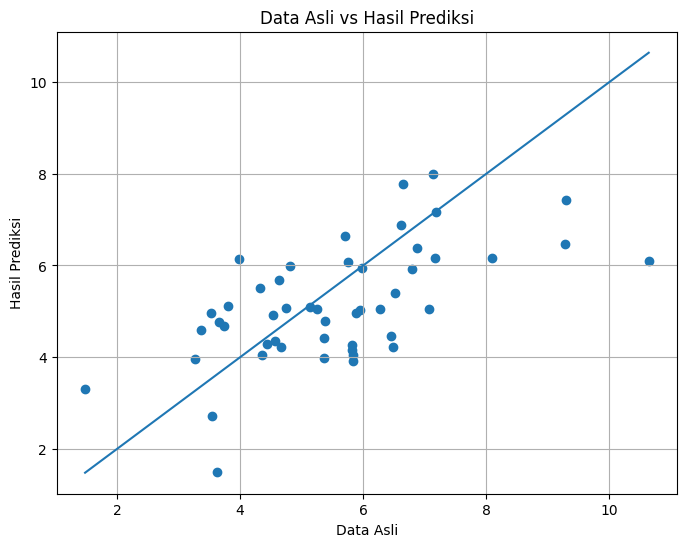

In [75]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_uji,
    y_prediksi
)

plt.plot(
    [y_uji.min(), y_uji.max()],
    [y_uji.min(), y_uji.max()]
)

plt.xlabel('Data Asli')

plt.ylabel('Hasil Prediksi')

plt.title(
    'Data Asli vs Hasil Prediksi'
)

plt.grid(True)

plt.show()

In [76]:
perbandingan['Selisih Error'] = abs(
    perbandingan['Data Asli'] -
    perbandingan['Hasil Prediksi']
)

perbandingan.sort_values(
    by='Selisih Error'
).head(10)

,Data Asli,Hasil Prediksi,Selisih Error
0,7.18,7.160084,0.019916
47,5.98,5.952876,0.027124
22,5.13,5.087409,0.042591
14,4.44,4.280219,0.159781
42,5.25,5.041912,0.208088
2,4.56,4.350367,0.209633
4,6.61,6.874313,0.264313
21,4.36,4.037937,0.322063
27,5.76,6.082190,0.322190
48,4.74,5.081148,0.341148


In [77]:
perbandingan.sort_values(
    by='Selisih Error',
    ascending=False
).head(10)

,Data Asli,Hasil Prediksi,Selisih Error
25,10.64,6.102565,4.537435
17,9.28,6.459648,2.820352
12,6.48,4.215713,2.264287
24,3.98,6.145303,2.165303
20,3.62,1.487611,2.132389
38,7.07,5.060300,2.009700
45,6.45,4.451385,1.998615
16,8.09,6.162435,1.927565
13,5.84,3.914990,1.925010
23,9.29,7.422987,1.867013


In [78]:
print(
    "Rata-rata Error:",
    round(
        perbandingan['Selisih Error'].mean(),
        4
    )
)

Rata-rata Error: 1.1544


In [79]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

r2 = r2_score(
    y_uji,
    y_prediksi
)

mae = mean_absolute_error(
    y_uji,
    y_prediksi
)

rmse = np.sqrt(
    mean_squared_error(
        y_uji,
        y_prediksi
    )
)

print("="*40)
print("HASIL EVALUASI MODEL")
print("="*40)

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

HASIL EVALUASI MODEL
R²   : 0.2906
MAE  : 1.1544
RMSE : 1.4240


In [80]:
import pandas as pd

hasil = pd.DataFrame({
    'Aktual': y_uji,
    'Prediksi': y_prediksi
})

hasil.head(20)

,Aktual,Prediksi
24,7.18,7.160084
6,3.74,4.689741
153,4.56,4.350367
212,5.94,5.031778
199,6.61,6.874313
177,6.28,5.059176
193,3.54,2.709452
124,5.81,4.146175
9,7.16,6.173050
101,4.81,5.995980


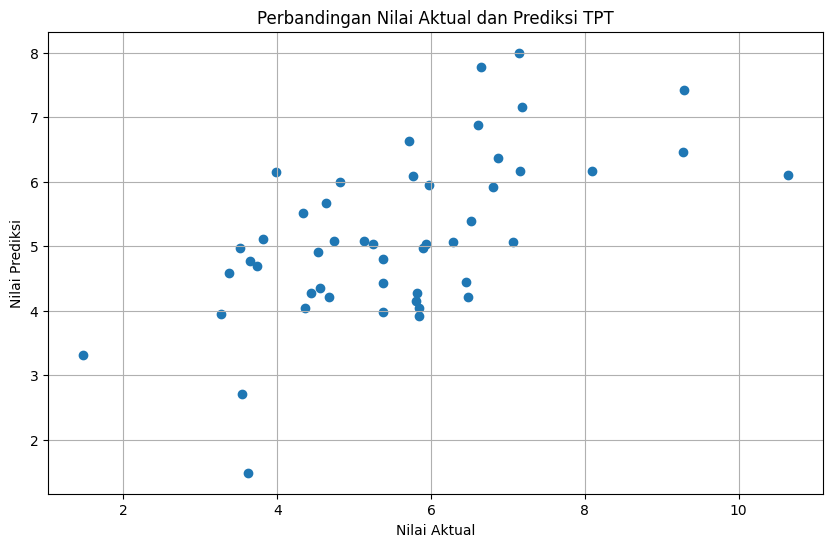

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    y_uji,
    y_prediksi
)

plt.xlabel("Nilai Aktual")

plt.ylabel("Nilai Prediksi")

plt.title(
    "Perbandingan Nilai Aktual dan Prediksi TPT"
)

plt.grid(True)

plt.show()

In [82]:
koef = pd.DataFrame({
    'Variabel': X.columns,
    'Koefisien': model.coef_
})

koef

,Variabel,Koefisien
0,Tingkat Partisipasi Angkatan Kerja (TPAK) - Ag...,-0.246758
1,Indeks Pembangunan Manusia,0.009901
2,Rata-rata Lama Sekolah,0.549715
3,Tahun,-0.010727


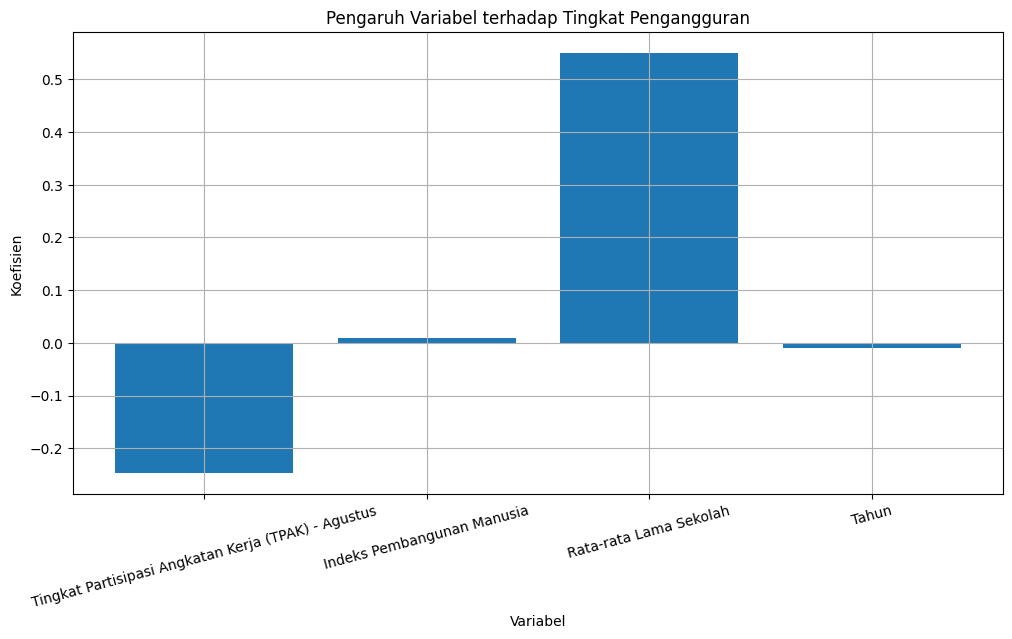

In [83]:
plt.figure(figsize=(12,6))

plt.bar(
    koef['Variabel'],
    koef['Koefisien']
)

plt.title(
    'Pengaruh Variabel terhadap Tingkat Pengangguran'
)

plt.xlabel('Variabel')

plt.ylabel('Koefisien')

plt.xticks(rotation=15)

plt.grid(True)

plt.show()

In [84]:
data_baru = pd.DataFrame({
    'Tingkat Partisipasi Angkatan Kerja (TPAK) - Agustus':[70],
    'Indeks Pembangunan Manusia':[75],
    'Rata-rata Lama Sekolah':[9],
    'Tahun':[2024]
})

prediksi = model.predict(data_baru)

print(
    "Prediksi Tingkat Pengangguran:",
    round(prediksi[0],2),
    "%"
)

Prediksi Tingkat Pengangguran: 4.78 %
